In [51]:
#created on 17/04/2026 by James McLoughlin

In [161]:
from pathlib import Path
import os
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import rasterio.merge
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [162]:
base = Path("C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set")

In [163]:
user_choice = {
    "NDVI": 1,
    "NDWI": 1,
    "NDSI": 0,
}

In [165]:
satbands = {
    "LT05": {
        "B1":"BLUE", 
        "B2":"GREEN",
        "B3":"RED",
        "B4":"NIR",
        "B5":"SWIR1",
        "B6":"TIR",
        "B7":"SWIR2"}}

index_to_bands = {
    "NDVI": ["RED", "NIR"],
    "NDWI": ["GREEN", "NIR"]
}

In [166]:
records = []
raw_data = base/"raw_data"
for folder in raw_data.iterdir():
    if folder.is_dir() and "Mosiac" not in folder.name:
        for file in folder.glob("*_SR_B*.TIF"):
            parts = file.name.split("_")
            sat = parts[0]
            band = parts[-1].replace(".TIF", "")
            records.append({
                "folder": folder.name,
                "file": file.name,
                "year": parts[3][:4],    # 1985
                "satellite": sat,
                "path": file,
                "pathrow": parts[2],     # 038031
                "band": band,
                "colour": satbands[sat][band]
            })
df = pd.DataFrame(records)

In [178]:
bands = set()
for idx, use in user_choice.items():
    if use:
        bands.update(index_to_bands[idx])

band_order = ["BLUE", "GREEN", "RED", "NIR", "SWIR1", "SWIR2"]
NDI = [b for b in band_order if b in bands]

In [179]:
mosaic_out = base/"Processed_data"/"Mosiac"
print(mosaic_out)
for yr in df["year"].unique():
    for colr in NDI:
        file_list = df[
            (df["year"] == yr) &
            (df["colour"] == colr)
            ]["path"].tolist()
        rio.merge.merge(file_list, dst_path = os.path.join(mosaic_out, f"{yr}_{colr}_mosaic.tif"))

C:\RS_GIS\EGM722\Assignment\great_salt_lake\USGS_data\Unzipped\single set\Processed_data\Mosiac


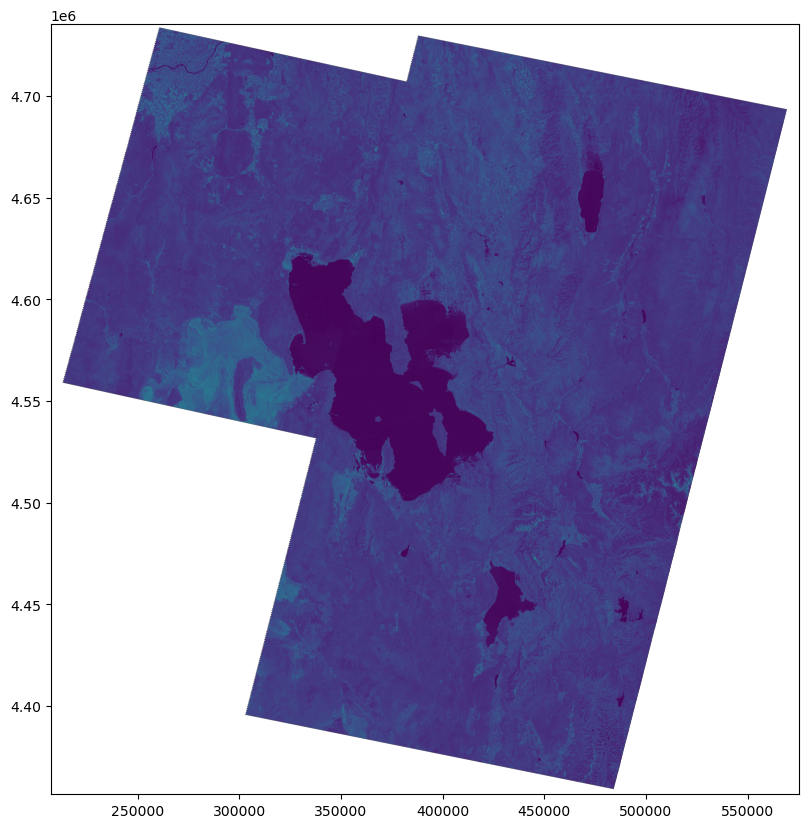

In [135]:
with rio.open("C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/Mosiac/mosiac.tif") as dataset:
    fig, ax = plt.subplots(figsize=(10, 10))
    show(dataset, ax=ax)   # <-- key change
plt.show()

In [121]:
target_year = "1985"
target_bands = ["GREEN"]

subset = df[
    (df["year"] == target_year) &
    (df["colour"].isin(target_bands))
    ]
file_list = subset["path"].tolist()

print(subset)print(file_list)

                                      folder  \
1   LT05_L2SP_038031_19850612_20200918_02_T1   
7   LT05_L2SP_038032_19850612_20200918_02_T1   
13  LT05_L2SP_039031_19850619_20200918_02_T1   

                                                 file  year satellite  \
1   LT05_L2SP_038031_19850612_20200918_02_T1_SR_B2...  1985      LT05   
7   LT05_L2SP_038032_19850612_20200918_02_T1_SR_B2...  1985      LT05   
13  LT05_L2SP_039031_19850619_20200918_02_T1_SR_B2...  1985      LT05   

                                                 path pathrow band colour  
1   C:\RS_GIS\EGM722\Assignment\great_salt_lake\US...  038031   B2  GREEN  
7   C:\RS_GIS\EGM722\Assignment\great_salt_lake\US...  038032   B2  GREEN  
13  C:\RS_GIS\EGM722\Assignment\great_salt_lake\US...  039031   B2  GREEN  
[WindowsPath('C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/LT05_L2SP_038031_19850612_20200918_02_T1/LT05_L2SP_038031_19850612_20200918_02_T1_SR_B2.TIF'), WindowsPath('C:/RS_GIS/EGM7

In [78]:
'''
def get_satellite_band(sat, band):
#    satellite = parse_usgs_filename(filename)
    #satellite = datafile.name.split("_")[0]  # LC08
    print(sat, band)
    if sat == "LT05":
        mapping = {
            "B1":"BLUE",
            "B2":"GREEN",
            "B2":"RED",
            "B2":"NIR",
            "B2":"SWIR1",
            "B2":"SWIR2",
        }
#        mapping = {
#            "BLUE":"B1",
#            "GREEN":"B2",
#            "RED":"B3",
#            "NIR":"B4",
#            "SWIR1":"B5",
#            "SWIR2":"B6",
#        }
    elif sat == "LC08":      
        mapping = {
            "BLUE":"B2",
            "GREEN": "B3",
            "RED": "B4",
            "NIR":"B5",
           }

    return [mapping[b] for b in band]
'''

In [99]:
'''
records = []

for folder, files in dataset.items():
    for f in files:
        parts = f.split("_")
        
        year = parts[3][:4]
        band = parts[-1].replace(".TIF", "")  # SR_B2 etc
        
        records.append({
            "folder": folder,
            "year": year,
            "band": band,
            "file": f
        })

print(records)
'''

'\nrecords = []\n\nfor folder, files in dataset.items():\n    for f in files:\n        parts = f.split("_")\n\n        year = parts[3][:4]\n        band = parts[-1].replace(".TIF", "")  # SR_B2 etc\n\n        records.append({\n            "folder": folder,\n            "year": year,\n            "band": band,\n            "file": f\n        })\n\nprint(records)\n'

In [100]:
'''
dataset = {}
folders = []
years = []
for subfolder in parent.iterdir():
    if subfolder.is_dir() and not subfolder.name.endswith(".tar") and "Mosiac" not in subfolder.name:
        files = [f.name for f in subfolder.glob("*_SR_B*.TIF")]
        dataset[subfolder.name] = files
folders = list(dataset.keys())
years = sorted({folder.split("_")[3][:4] for folder in folders})

for folder, files in dataset.items():
    print(folder)
    for f in files:
        print(f"  {f}")
    print()
    
print(folders)
print(years)
'''

'\ndataset = {}\nfolders = []\nyears = []\nfor subfolder in parent.iterdir():\n    if subfolder.is_dir() and not subfolder.name.endswith(".tar") and "Mosiac" not in subfolder.name:\n        files = [f.name for f in subfolder.glob("*_SR_B*.TIF")]\n        dataset[subfolder.name] = files\nfolders = list(dataset.keys())\nyears = sorted({folder.split("_")[3][:4] for folder in folders})\n\nfor folder, files in dataset.items():\n    print(folder)\n    for f in files:\n        print(f"  {f}")\n    print()\n\nprint(folders)\nprint(years)\n'

In [33]:
#NDVI = 0
#NDWI = 1
#if NDVI == 0:
#    colours = "RED", "NIR"
#if NDWI == 1:
#    colours = "GREEN", "NIR"

['1985']


In [26]:


colours = "GREEN", "NIR"

#downselect files needed for analysis
AnalysisSet = []
for year in years:
    for folder in folders:
        satbands = get_satellite_bands(folder,colours)
        for file in dataset[folder]:
            if any("B2.TIF" in file for code in satbands):
                #AnalysisSet.append(file)
                AnalysisSet.append(parent / Path(folder) / file)
print(AnalysisSet)            

[WindowsPath('C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/LT05_L2SP_038031_19850612_20200918_02_T1/LT05_L2SP_038031_19850612_20200918_02_T1_SR_B2.TIF'), WindowsPath('C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/LT05_L2SP_038032_19850612_20200918_02_T1/LT05_L2SP_038032_19850612_20200918_02_T1_SR_B2.TIF'), WindowsPath('C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/LT05_L2SP_039031_19850619_20200918_02_T1/LT05_L2SP_039031_19850619_20200918_02_T1_SR_B2.TIF')]


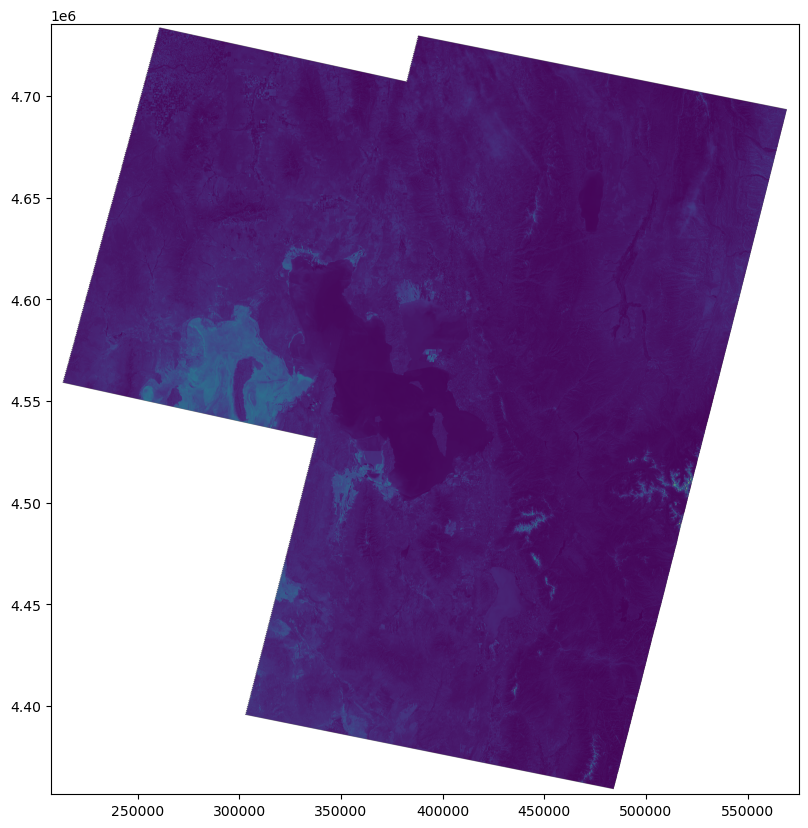

In [27]:

rio.merge.merge(AnalysisSet, dst_path="C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/Mosiac/mosiac.tif")



with rio.open("C:/RS_GIS/EGM722/Assignment/great_salt_lake/USGS_data/Unzipped/single set/Mosiac/mosiac.tif") as dataset:
    
    fig, ax = plt.subplots(figsize=(10, 10))
    show(dataset, ax=ax)   # <-- key change

plt.show()


In [55]:
def clipping(datafile):
    for file in parent.rglob(datafile):
        print(file)
        with rio.open(file) as data:
            geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
            out_image, out_transform = mask(data, geom, crop=True)
            fig, ax2 = plt.subplots(figsize=(10, 10))
            show(out_image, ax=ax2)